# مشروع نمذجة مخاطر التعثر: دورة حياة البيانات كاملة

**هدف المشروع:** تقدير احتمال تعثر سداد البطاقة الائتمانية في الشهر القادم من السجل المالي للأشهر السابقة. هذا الملف مستقل: **البيانات مضمنة داخله**، وجميع مراحل التحليل والتدريب والتنبؤ موجودة في خلاياه. لا يحتاج ملف XLS أو ملفات Python أخرى.

**طريقة التشغيل:** اختر Kernel من بيئة Python 3.12، ثم نفّذ الخلايا من الأعلى إلى الأسفل. يحتاج `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `joblib`. إذا لم تثبتها، شغّل في Terminal: `python -m pip install pandas==2.2.3 numpy==2.3.5 matplotlib==3.10.8 scikit-learn==1.8.0 joblib==1.5.3`.

**المصدر:** [UCI Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)، تايوان، 2005؛ نسخة البيانات جاءت من الملف الذي زوّدتني به. نتائج هذا المشروع تعليمية ولا تشكّل قرارًا ائتمانيًا أو قرار تحصيل.

## 0. خريطة العمل

1. تحميل البيانات وفهم الأعمدة والهدف. 2. جودة البيانات والاستكشاف. 3. فصل الاختبار قبل قرارات النمذجة. 4. كشف القيم الشاذة ووضع سياسة للتعامل معها. 5. هندسة ميزات مالية. 6. خط أساس ومقارنة نموذجين. 7. معايرة وتقييم على اختبار محجوز. 8. تفسير وفحص فئات. 9. حفظ النموذج والتنبؤ لسجل جديد. 10. محاكاة API ومراقبة أولية.

**مهم:** لا نملك تواريخ قرار لكل عميل، لذلك لا نستطيع إجراء اختبار زمني حقيقي. وكذلك الهدف المتاح هو **التعثر** وليس **احتمال السداد بعد التعثر**.

In [1]:
import base64, gzip, io, json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             precision_recall_curve, roc_curve, confusion_matrix)
from sklearn.inspection import permutation_importance

print("Python:", sys.version.split()[0], "pandas:", pd.__version__,
      "scikit-learn:", sklearn.__version__)
SEED = 42
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.25})

Python: 3.12.14 pandas: 2.2.3 scikit-learn: 1.8.0


## 1. تحميل البيانات: ملف واحد فقط

الخلية التالية تحمل نسخة CSV مضغوطة من ملف `.xls` الأصلي داخل الـNotebook. يمكنك ترك الشيفرة مخفية في Jupyter. بعد فك الضغط، `df` جدول pandas عادي يحوي كل الصفوف والأعمدة، دون تنزيل خارجي.

In [2]:
EMBEDDED_GZIP_CSV_BASE64 = "..."
df = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(EMBEDDED_GZIP_CSV_BASE64))))
TARGET = "default payment next month"
RAW_FEATURES = (["LIMIT_BAL"] + [f"PAY_{i}" for i in [0, 2, 3, 4, 5, 6]]
                + [f"BILL_AMT{i}" for i in range(1, 7)]
                + [f"PAY_AMT{i}" for i in range(1, 7)])
assert df.shape == (30000, 25)
assert df[TARGET].isin([0, 1]).all()
print("rows, columns:", df.shape)
print(df.head(3).to_string(index=False))

rows, columns: (30000, 25)
 ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month
  1      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0         0       689         0         0         0         0                           1
  2     120000    2          2         2   26     -1      2      0      0      0      2       2682       1725       2682       3272       3455       3261         0      1000      1000      1000         0      2000                           1
  3      90000    2          2         2   34      0      0      0      0      0      0      29239      14027      13559      14331      14948      15549      1518      1500      1000      1000      1000      5000                           0


### قاموس البيانات المختصر

| العمود | المعنى |
|---|---|
| `ID` | معرّف السجل؛ **لا يدخل** النموذج. |
| `LIMIT_BAL` | الحد الائتماني بالدولار التايواني الجديد. |
| `PAY_0`, `PAY_2` … `PAY_6` | حالات السداد من الأحدث إلى الأقدم؛ قيم موجبة تشير إلى أشهر تأخر، و0/القيم السالبة تحتاج قراءة حذرة حسب توثيق المصدر. |
| `BILL_AMT1` … `BILL_AMT6` | مبالغ الفواتير السابقة. قد تظهر قيمة سالبة؛ لا نعُدّها خطأ تلقائيًا. |
| `PAY_AMT1` … `PAY_AMT6` | المبالغ المدفوعة سابقًا. |
| `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` | خصائص ديموغرافية مستبعدة من تدريب النموذج؛ الجنس والعمر يُستخدمان في تدقيق وصفي لاحقًا. |
| `default payment next month` | الهدف: `1` تعثر الشهر القادم، `0` عدم التعثر. |

البيانات **مقطع واحد لكل عميل**، لذلك سجل الأشهر السابقة متاح كتاريخ داخل الصف، لكنه لا يجعل لدينا تواريخ مستقلة لتقسيم كل العملاء زمنيًا.

## 2. فحص الجودة الأساسي

نراجع نوع الأعمدة، القيم الناقصة، المعرّفات المكررة، وفئات غير موثقة جيدًا. لا نغيّر قيمًا لمجرد أنها نادرة.

In [3]:
print("أنواع البيانات:", df.dtypes.value_counts().to_string())
print("Missing cells:", int(df.isna().sum().sum()))
print("Duplicate ID:", int(df.ID.duplicated().sum()))
print("Duplicate full rows:", int(df.duplicated().sum()))
print("Target counts:", df[TARGET].value_counts().sort_index().to_string())
print("Default prevalence:", round(df[TARGET].mean(), 4))
print("Education outside 1..4:", int((~df.EDUCATION.isin([1, 2, 3, 4])).sum()))
print("Marriage = 0:", int((df.MARRIAGE == 0).sum()))
print("PAY_0 = -2:", int((df.PAY_0 == -2).sum()))
assert df[RAW_FEATURES].notna().all().all()

أنواع البيانات: int64    25
Missing cells: 0
Duplicate ID: 0
Duplicate full rows: 0
Target counts: default payment next month
0    23364
1     6636
Default prevalence: 0.2212
Education outside 1..4: 345
Marriage = 0: 54
PAY_0 = -2: 2759


## 3. استكشاف توزيع الهدف والعلاقات الأولية

نسبة التعثر قرابة 22%؛ لذلك الاعتماد على Accuracy وحدها قد يكون مضللًا. نعرض أيضًا علاقة حالة السداد الأخيرة بالنتيجة. هذه علاقة وصفية، وليست إثباتًا للسببية.

           mean  count
PAY_0                 
-2     0.132294   2759
-1     0.167781   5686
 0     0.128113  14737
 1     0.339479   3688
 2     0.691414   2667
 3     0.757764    322
 4     0.684211     76
 5     0.500000     26
 6     0.545455     11
 7     0.777778      9
 8     0.578947     19


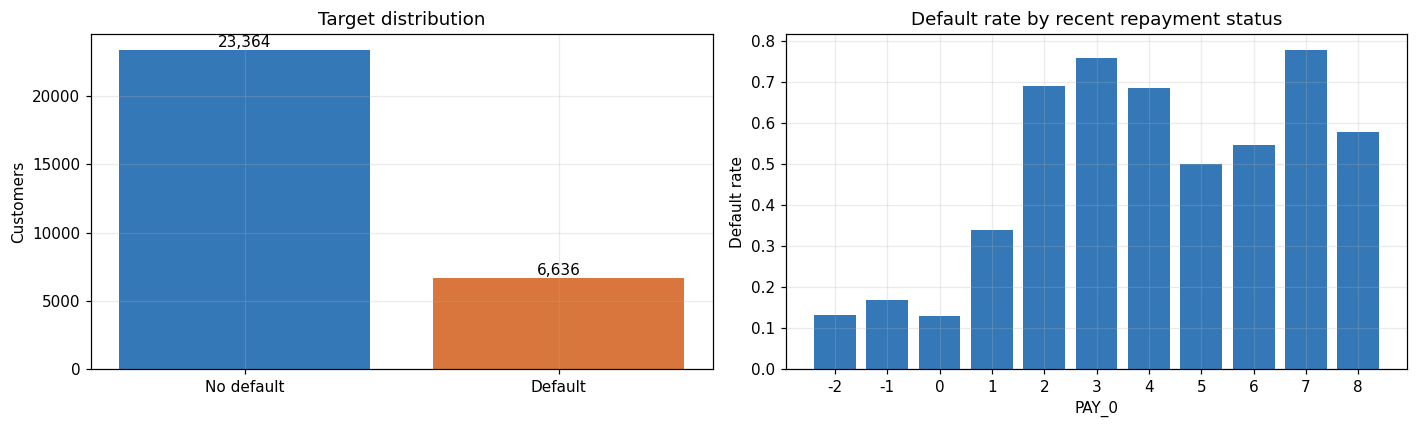

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df[TARGET].value_counts().sort_index()
axes[0].bar(["No default", "Default"], counts.values, color=["#3478b7", "#d8763d"])
axes[0].set(title="Target distribution", ylabel="Customers")
for i, count in enumerate(counts.values): axes[0].text(i, count+250, f"{count:,}", ha="center")
by_delay = df.groupby("PAY_0")[TARGET].agg(["mean", "count"])
axes[1].bar(by_delay.index.astype(str), by_delay["mean"], color="#3478b7")
axes[1].set(title="Default rate by recent repayment status", ylabel="Default rate", xlabel="PAY_0")
plt.tight_layout(); plt.show()
print(by_delay.to_string())

## 4. تقسيم البيانات قبل قرارات النمذجة

نحجز **20% للاختبار النهائي**، ونستخدم 60% تدريبًا و20% تحققًا. `stratify` يحافظ على نسبة الفئتين في كل مجموعة. لا نستخدم الاختبار لاختيار النموذج أو قيم المعالجة. التقسيم عشوائي لأن الملف لا يوفر تاريخ قرار مستقلًا لكل عميل.

In [5]:
idx_dev, idx_test = train_test_split(df.index, test_size=0.20,
                                        stratify=df[TARGET], random_state=SEED)
idx_train, idx_val = train_test_split(idx_dev, test_size=0.25,
                                     stratify=df.loc[idx_dev, TARGET], random_state=SEED)
train_df, val_df, test_df = df.loc[idx_train].copy(), df.loc[idx_val].copy(), df.loc[idx_test].copy()
for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(name, len(part), "default_rate", round(part[TARGET].mean(), 4))
assert not (set(idx_train) & set(idx_test)) and not (set(idx_val) & set(idx_test))

train 18000 default_rate 0.2212
validation 6000 default_rate 0.2212
test 6000 default_rate 0.2212


## 5. اكتشاف القيم الشاذة Outliers

نستخدم مجموعة **التدريب فقط** لحساب الربيعات وحدود IQR: `Q1 - 1.5×IQR` و`Q3 + 1.5×IQR`. هذا يكشف أطراف التوزيع إحصائيًا؛ لا يثبت أن السجل خاطئ. المبالغ المالية قد تكون منحرفة طبيعيًا بسبب اختلاف حدود العملاء وأحجام الفواتير.

  feature     min   median       p99    max   iqr_low  iqr_high  iqr_flags  flag_rate
LIMIT_BAL   10000 140000.0 500000.00 800000 -235000.0  525000.0         96      0.005
BILL_AMT1 -165580  22339.0 342622.88 621749  -91172.5  161169.5       1419      0.079
 PAY_AMT1       0   2100.0  69033.88 873552   -5013.5   11022.5       1634      0.091


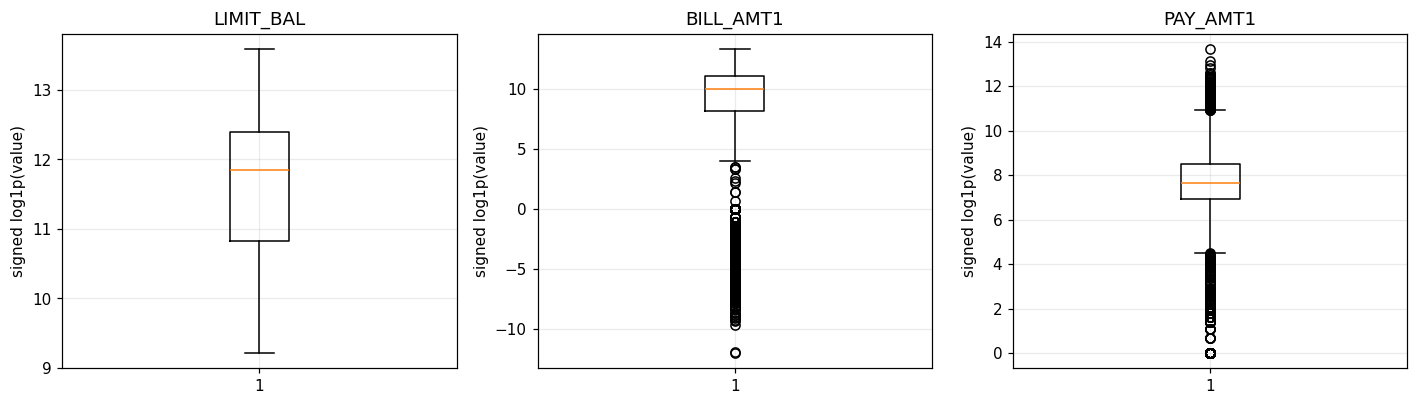

In [6]:
review_cols = ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]
rows = []
for column in review_cols:
    s = train_df[column]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    flag = (s < low) | (s > high)
    rows.append({"feature":column, "min":s.min(), "median":s.median(),
                 "p99":s.quantile(0.99), "max":s.max(), "iqr_low":low,
                 "iqr_high":high, "iqr_flags":int(flag.sum()),
                 "flag_rate":float(flag.mean())})
outlier_review = pd.DataFrame(rows)
print(outlier_review.round(3).to_string(index=False))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, column in zip(axes, review_cols):
    transformed = np.sign(train_df[column]) * np.log1p(np.abs(train_df[column]))
    ax.boxplot(transformed, orientation="vertical")
    ax.set(title=column, ylabel="signed log1p(value)")
plt.tight_layout(); plt.show()

### قرارنا بشأن القيم الشاذة

**لا نحذفها ولا نقصّها آليًا.** IQR يرفع أعلامًا كثيرة في بيانات مالية منحرفة، ولا يوجد دليل في الملف يثبت فساد تلك القيم. نستخدم `RobustScaler` في الانحدار اللوجستي لأنه يعتمد على الوسيط والمدى الربيعي، ونقارن أيضًا نموذج أشجار. إذا توفرت سياسة بيانات حقيقية، نتحقق من القيم الشاذة في مصدرها أولًا. هذا قرار موثق، لا تجاهل للـOutliers.

## 6. هندسة متغيرات Feature Engineering

نشتق ثلاث ميزات من معلومات متاحة قبل الشهر المستهدف: نسبة أحدث فاتورة إلى الحد، أكبر تأخر موجب عبر ستة أشهر، وإجمالي المدفوعات نسبة إلى الحد. جميعها تُحسب **داخل صف العميل وحده**؛ لا تستخدم الهدف ولا إحصاءات الاختبار.

In [7]:
DERIVED = ["BILL_TO_LIMIT_1", "MAX_DELAY_6", "PAYMENT_SUM_TO_LIMIT_6"]
FEATURES = RAW_FEATURES + DERIVED
def make_features(frame):
    X = frame[RAW_FEATURES].copy()
    limit = X["LIMIT_BAL"].clip(lower=1)
    X["BILL_TO_LIMIT_1"] = X["BILL_AMT1"] / limit
    X["MAX_DELAY_6"] = X[["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]].clip(lower=0).max(axis=1)
    X["PAYMENT_SUM_TO_LIMIT_6"] = X[[f"PAY_AMT{i}" for i in range(1,7)]].sum(axis=1) / limit
    return X[FEATURES]
X_train, X_val, X_test = (make_features(part) for part in [train_df, val_df, test_df])
y_train, y_val, y_test = (part[TARGET].astype(int) for part in [train_df, val_df, test_df])
print("Model features:", len(FEATURES), FEATURES)
print(X_train[DERIVED].describe().round(3).to_string())
assert np.isfinite(X_train.to_numpy()).all()

Model features: 22 ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'BILL_TO_LIMIT_1', 'MAX_DELAY_6', 'PAYMENT_SUM_TO_LIMIT_6']
       BILL_TO_LIMIT_1  MAX_DELAY_6  PAYMENT_SUM_TO_LIMIT_6
count        18000.000    18000.000               18000.000
mean             0.421        0.687                   0.233
std              0.412        1.069                   0.303
min             -0.620        0.000                   0.000
25%              0.022        0.000                   0.067
50%              0.310        0.000                   0.157
75%              0.824        2.000                   0.264
max              6.455        8.000                  11.071


## 7. خط أساس ومقارنة نموذجين

`DummyClassifier` يعيد النسبة الأساسية تقريبًا؛ نستخدمه مرجعًا. ثم Logistic Regression كنموذج مفهوم، وHistGradientBoosting لالتقاط العلاقات غير الخطية. المعالجة الإحصائية مثل `RobustScaler` داخل Pipeline، لذلك تتعلم من التدريب فقط وتطبق نفس التحويل على التحقق والبيانات الجديدة.

**معيار الاختيار:** أعلى PR-AUC على مجموعة التحقق. نعرض كذلك ROC-AUC وBrier؛ الأصغر أفضل للأخير.

In [8]:
def summary_metrics(y, p, fraction=0.20):
    y, p = np.asarray(y, dtype=int), np.asarray(p, dtype=float)
    k = max(1, int(np.ceil(len(y)*fraction)))
    selected = np.argsort(-p, kind="stable")[:k]
    prevalence = float(y.mean())
    return {"n": len(y), "default_rate": prevalence,
            "pr_auc": float(average_precision_score(y,p)),
            "roc_auc": float(roc_auc_score(y,p)),
            "brier": float(brier_score_loss(y,p)),
            "top20_default_rate": float(y[selected].mean()),
            "top20_capture": float(y[selected].sum()/y.sum()),
            "top20_lift": float(y[selected].mean()/prevalence)}

models = {
    "baseline": DummyClassifier(strategy="prior"),
    "logistic": make_pipeline(SimpleImputer(strategy="median"), RobustScaler(),
                              LogisticRegression(max_iter=2000, random_state=SEED)),
    "gradient_boosting": make_pipeline(SimpleImputer(strategy="median"),
        HistGradientBoostingClassifier(max_iter=120, max_leaf_nodes=15,
                                       learning_rate=0.05, random_state=SEED)),
}
validation_results = {}
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    val_prob = estimator.predict_proba(X_val)[:,1]
    validation_results[name] = summary_metrics(y_val, val_prob)
print(pd.DataFrame(validation_results).T.round(4).to_string())
selected_name = max(["logistic", "gradient_boosting"],
                    key=lambda name: validation_results[name]["pr_auc"])
print("Selected by validation PR-AUC:", selected_name)

                        n  default_rate  pr_auc  roc_auc   brier  top20_default_rate  top20_capture  top20_lift
baseline           6000.0        0.2212  0.2212   0.5000  0.1723              0.2283         0.2065      1.0324
logistic           6000.0        0.2212  0.4973   0.7415  0.1433              0.5483         0.4959      2.4793
gradient_boosting  6000.0        0.2212  0.5548   0.7834  0.1343              0.5708         0.5162      2.5810
Selected by validation PR-AUC: gradient_boosting


## 8. إعادة التدريب ومعايرة الاحتمالات

بعد الاختيار، نجمع التدريب والتحقق (**24,000 سجل**) ونُنشئ نسخة جديدة من النموذج المختار. `CalibratedClassifierCV` يبني تنبؤات عبر ثلاث طيات داخل بيانات التطوير لتعلّم معايرة sigmoid دون استخدام الاختبار. نفتح الاختبار بعد إكمال اختيار النموذج.

In [9]:
from sklearn.base import clone
dev_df = df.loc[idx_dev]
X_dev, y_dev = make_features(dev_df), dev_df[TARGET].astype(int)
final_model = CalibratedClassifierCV(estimator=clone(models[selected_name]),
                                     method="sigmoid", cv=3)
final_model.fit(X_dev, y_dev)
p_test = final_model.predict_proba(X_test)[:,1]
p_dev = final_model.predict_proba(X_dev)[:,1]
test_metrics = summary_metrics(y_test, p_test)
print(pd.Series(test_metrics).round(4).to_string())

n                     6000.0000
default_rate             0.2212
pr_auc                   0.5538
roc_auc                  0.7777
brier                    0.1353
top20_default_rate       0.5567
top20_capture            0.5034
top20_lift               2.5170


## 9. تقييم الاختبار النهائي

**PR-AUC** مفيد عند عدم توازن الفئات. **ROC-AUC** يصف قدرة التمييز. **Brier** يقيس جودة الاحتمالات، و**Top 20% Capture** يحاكي فريقًا يستطيع مراجعة أعلى خُمس الملفات خطرًا. المقاييس هنا تصف البيانات المحجوزة؛ لا تعني تحصيلًا ماليًا محققًا.

Confusion matrix at illustrative threshold 0.5 (rows actual, columns predicted):
[[4437  236]
 [ 846  481]]
0.5 is an illustration, not an approved business decision threshold.


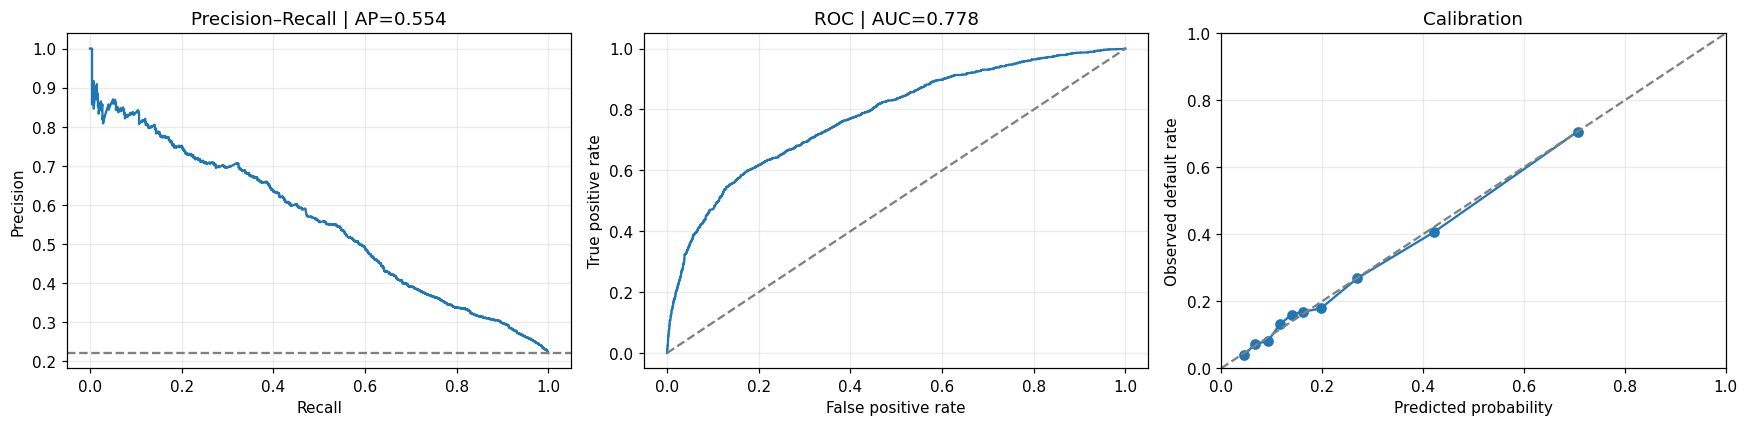

In [10]:
precision, recall, _ = precision_recall_curve(y_test, p_test)
fpr, tpr, _ = roc_curve(y_test, p_test)
observed, predicted = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(recall, precision); axes[0].axhline(y_test.mean(), ls="--", color="gray")
axes[0].set(title=f"Precision–Recall | AP={test_metrics['pr_auc']:.3f}", xlabel="Recall", ylabel="Precision")
axes[1].plot(fpr, tpr); axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set(title=f"ROC | AUC={test_metrics['roc_auc']:.3f}", xlabel="False positive rate", ylabel="True positive rate")
axes[2].plot(predicted, observed, "o-"); axes[2].plot([0,1],[0,1],"--",color="gray")
axes[2].set(title="Calibration", xlabel="Predicted probability", ylabel="Observed default rate", xlim=(0,1), ylim=(0,1))
plt.tight_layout(); plt.show()
print("Confusion matrix at illustrative threshold 0.5 (rows actual, columns predicted):")
print(confusion_matrix(y_test, p_test >= .5))
print("0.5 is an illustration, not an approved business decision threshold.")

### ترتيب الملفات عبر نسب مختلفة

إذا كان بإمكان الفريق مراجعة 10% أو 20% أو 30% من الملفات، كم نسبة حالات التعثر التي تظهر في تلك المجموعة؟ **هذا ترتيب تجريبي على بيانات الاختبار، وليس قرار تواصل فعليًا.**

In [11]:
order = np.argsort(-p_test, kind="stable")
ranking = []
for share in [0.10, 0.20, 0.30, 0.50]:
    top = order[:int(np.ceil(len(order)*share))]
    ranking.append({"portfolio_share":share, "customers":len(top),
                    "default_rate_in_group":float(y_test.iloc[top].mean()),
                    "defaults_captured":float(y_test.iloc[top].sum()/y_test.sum())})
print(pd.DataFrame(ranking).round(4).to_string(index=False))

 portfolio_share  customers  default_rate_in_group  defaults_captured
             0.1        600                 0.7067             0.3195
             0.2       1200                 0.5567             0.5034
             0.3       1800                 0.4606             0.6247
             0.5       3000                 0.3457             0.7815


## 10. تفسير النموذج

نخلط قيم عمود واحد في الاختبار ونقيس هبوط PR-AUC. هذه **أهمية عالمية** وليست تفسيرًا فرديًا أو أثرًا سببيًا. الأعمدة المترابطة قد تتقاسم الإشارة، لذلك لا تفسّر رقمًا صغيرًا كعدم فائدة قطعية.

               feature  pr_auc_drop_mean  pr_auc_drop_std
                 PAY_0            0.1071           0.0102
           MAX_DELAY_6            0.0701           0.0086
             BILL_AMT1            0.0109           0.0033
       BILL_TO_LIMIT_1            0.0051           0.0014
PAYMENT_SUM_TO_LIMIT_6            0.0040           0.0009
             LIMIT_BAL            0.0039           0.0014
                 PAY_5            0.0039           0.0027
                 PAY_6            0.0026           0.0005
              PAY_AMT2            0.0025           0.0005
             BILL_AMT5            0.0018           0.0004
              PAY_AMT1            0.0018           0.0009
              PAY_AMT3            0.0017           0.0005


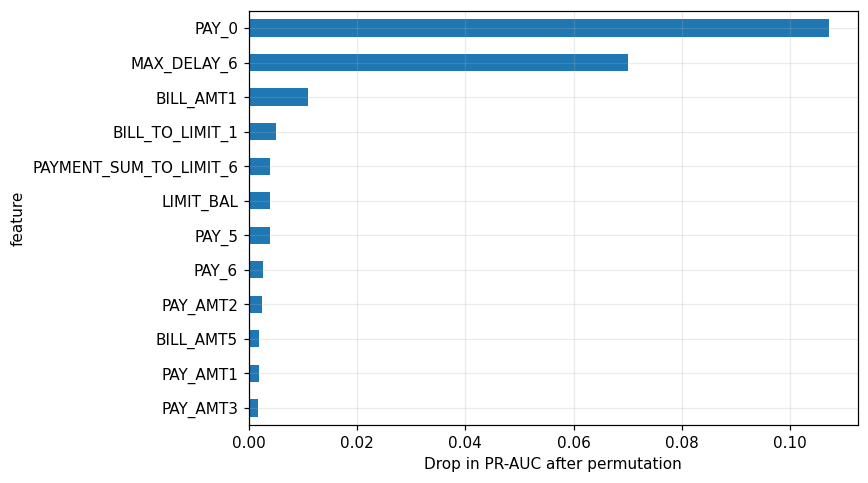

In [12]:
permutation = permutation_importance(final_model, X_test, y_test,
                                     scoring="average_precision", n_repeats=3,
                                     random_state=SEED, n_jobs=1)
importance = pd.DataFrame({"feature": FEATURES,
    "pr_auc_drop_mean": permutation.importances_mean,
    "pr_auc_drop_std": permutation.importances_std}).sort_values("pr_auc_drop_mean", ascending=False)
print(importance.head(12).round(4).to_string(index=False))
importance.head(12).sort_values("pr_auc_drop_mean").plot.barh(x="feature", y="pr_auc_drop_mean", legend=False)
plt.xlabel("Drop in PR-AUC after permutation"); plt.tight_layout(); plt.show()

## 11. فحص وصفي حسب الجنس والعمر

استبعدنا السمات الديموغرافية من المدخلات، لكن نفحص الفرق في الأداء بين مجموعات الاختبار. اختلاف النسب الأساسية والأحجام يغيّر تفسير PR-AUC؛ لا يمكن إعلان «إنصاف النموذج» من هذا الجدول وحده.

In [13]:
audit = test_df[[TARGET,"SEX","AGE"]].copy()
audit["score"] = p_test
audit["age_group"] = pd.cut(audit.AGE, [0,30,45,60,np.inf], labels=["<=30","31-45","46-60","61+"])
group_rows = []
for column in ["SEX","age_group"]:
    for group, subset in audit.groupby(column, observed=True):
        if subset[TARGET].nunique() < 2: continue
        m = summary_metrics(subset[TARGET], subset.score)
        group_rows.append({"group_type":column,"group":str(group),"n":m["n"],
                           "base_rate":m["default_rate"],"pr_auc":m["pr_auc"],
                           "brier":m["brier"],"top20_capture":m["top20_capture"]})
group_report = pd.DataFrame(group_rows)
print(group_report.round(4).to_string(index=False))

group_type group    n  base_rate  pr_auc  brier  top20_capture
       SEX     1 2402     0.2336  0.5474 0.1437         0.4759
       SEX     2 3598     0.2129  0.5600 0.1296         0.5287
 age_group  <=30 2181     0.2196  0.5611 0.1317         0.5240
 age_group 31-45 2853     0.2117  0.5416 0.1332         0.5000
 age_group 46-60  908     0.2533  0.5759 0.1502         0.4783
 age_group   61+   58     0.2414  0.6144 0.1362         0.5000


## 12. حفظ النموذج والتنبؤ بعميل جديد

نحفظ النموذج ومعه أسماء المدخلات ونسخته. في التشغيل الحقيقي تُرسل القيم المالية نفسها فقط؛ `ID` والنتيجة `Y` ليسا مدخلات. الدالة تتحقق من وجود الأعمدة ومن القيم قبل حساب الاحتمال. ملف `joblib` الناتج ملف إضافي **ينشئه الـNotebook**، وليس مطلوبًا لفتح الملف الأصلي؛ ولا تحمّل ملفات `joblib` من مصدر غير موثوق.

In [14]:
MODEL_VERSION = "notebook-1.0"
bundle = {"model": final_model, "raw_features":RAW_FEATURES,
          "feature_names":FEATURES, "version":MODEL_VERSION,
          "reference_scores":p_dev}
model_path = Path("credit_default_model.joblib")
joblib.dump(bundle, model_path)
def predict_new_customer(record, saved_bundle=bundle):
    missing, extra = set(saved_bundle["raw_features"])-set(record), set(record)-set(saved_bundle["raw_features"])
    if missing or extra: raise ValueError(f"missing={sorted(missing)}, extra={sorted(extra)}")
    one = pd.DataFrame([record], columns=saved_bundle["raw_features"]).apply(pd.to_numeric, errors="raise")
    if not np.isfinite(one.to_numpy(dtype=float)).all() or one.LIMIT_BAL.iloc[0] <= 0:
        raise ValueError("All inputs must be finite; LIMIT_BAL must be positive")
    p = float(saved_bundle["model"].predict_proba(make_features(one))[:,1][0])
    return {"default_probability_next_month":round(p,6),
            "model_version":saved_bundle["version"]}

# سجل مثال من الملف الأصلي، للشرح فقط؛ ليس مثالًا خارجيًا مستقلًا.
example = df.loc[0, RAW_FEATURES].to_dict()
print(predict_new_customer(example))
restored = joblib.load(model_path) # ملف أنشأناه للتو، لذا مصدره موثوق.
print("After loading saved model:", predict_new_customer(example, restored))

{'default_probability_next_month': 0.709864, 'model_version': 'notebook-1.0'}
After loading saved model: {'default_probability_next_month': 0.709864, 'model_version': 'notebook-1.0'}


## 13. واجهة API محلية داخل الـNotebook

نبدأ خادم HTTP مؤقتًا على جهازك (`127.0.0.1`)، نرسل إليه طلب JSON واحد، ثم نوقفه. بهذه الطريقة ترى كيف يستقبل التطبيق بيانات **لم تكن ضمن عملية التدريب الجارية** ويعيد الاحتمال، دون ملف `api.py` منفصل. المثال نفسه مأخوذ من البيانات الأصلية، لذلك لا نعد النتيجة الفردية اختبارًا مستقلاً.

In [15]:
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from threading import Thread
from urllib.request import Request, urlopen

class RiskHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        if self.path != "/predict": self.send_error(404); return
        try:
            length = int(self.headers.get("Content-Length","0"))
            if length < 1 or length > 100_000: raise ValueError("Invalid request size")
            body = json.loads(self.rfile.read(length))
            output = predict_new_customer(body)
            status = 200
        except (ValueError, TypeError, json.JSONDecodeError) as exc:
            output, status = {"error":str(exc)}, 400
        payload = json.dumps(output).encode()
        self.send_response(status)
        self.send_header("Content-Type","application/json")
        self.send_header("Content-Length",str(len(payload)))
        self.end_headers(); self.wfile.write(payload)
    def log_message(self, *args): pass

server = ThreadingHTTPServer(("127.0.0.1",0), RiskHandler)
thread = Thread(target=server.serve_forever, daemon=True); thread.start()
try:
    request = Request(f"http://127.0.0.1:{server.server_port}/predict",
                      data=json.dumps(example).encode(), headers={"Content-Type":"application/json"})
    with urlopen(request) as response:
        print("HTTP", response.status, json.load(response))
finally:
    server.shutdown(); server.server_close(); thread.join()
print("Local API stopped. Deployment would require HTTPS, authentication, logging and controls.")

HTTP 200 {'default_probability_next_month': 0.709864, 'model_version': 'notebook-1.0'}
Local API stopped. Deployment would require HTTPS, authentication, logging and controls.


## 14. مراقبة النموذج عند وصول بيانات جديدة

في منتج حقيقي تقارن درجات فترة جديدة بدرجات مرجعية؛ هنا نستخدم الاختبار فقط **كمحاكاة** للمراقبة، ونحسب PSI، ثم الأداء لأن نتائج الاختبار معروفة. PSI لا يقول وحده إن النموذج فشل، ولا يعتبر تقسيمًا زمنيًا حقيقيًا.

In [16]:
def score_psi(reference, current, bins=10):
    a, b = np.asarray(reference,float), np.asarray(current,float)
    edges = np.unique(np.quantile(a, np.linspace(0,1,bins+1)))
    edges[0], edges[-1] = -np.inf, np.inf
    ref = np.maximum(np.histogram(a,bins=edges)[0]/len(a),1e-6)
    new = np.maximum(np.histogram(b,bins=edges)[0]/len(b),1e-6)
    return float(np.sum((new-ref)*np.log(new/ref)))

print("PSI, development vs simulated incoming batch:", round(score_psi(p_dev,p_test),4))
print("Observed performance when labels become available:")
print(pd.Series(summary_metrics(y_test,p_test)).round(4).to_string())

PSI, development vs simulated incoming batch: 0.001
Observed performance when labels become available:
n                     6000.0000
default_rate             0.2212
pr_auc                   0.5538
roc_auc                  0.7777
brier                    0.1353
top20_default_rate       0.5567
top20_capture            0.5034
top20_lift               2.5170


## 15. ماذا تعلمنا وما الخطوة التالية؟

- تتكامل دورة العمل من البيانات الخام إلى التنبؤ، لكن **النتائج لا تنتقل تلقائيًا للسوق السعودي**؛ الملف من تايوان عام 2005.
- Outliers المحتملة موثقة ولم نحذفها آليًا. المقارنة والتقييم على اختبار منفصل، لكن **لا يوجد اختبار زمني**.
- المتغيرات الأهم تصف اعتماد النموذج ولا تثبت السببية. فحص الفئات وصفي ولا يغني عن مراجعة إنصاف وامتثال متخصصة.
- **النموذج لا يتعلم تلقائيًا** عند التنبؤ. عند وصول بيانات جديدة مع نتائجها الحقيقية، نراقب الأداء والانحراف ثم نعيد التدريب والإصدار عند الحاجة.
- لبناء نموذج **احتمالية السداد بعد التعثر** تحتاج بيانات ملفات متعثرة، تاريخ قرار التواصل، قناة وتوقيت التدخل، الدفع اللاحق، مبالغ الاسترداد، والالتزامات التشغيلية. لا تختلق LGD أو أثر التحصيل من هذه البيانات.

**للمقابلة:** «بنيت نموذج تعثر من 30 ألف سجل، قارنت نموذجين، راجعت القيم الشاذة والإنصاف وصحة الاحتمالات، ثم جهزت تنبؤًا مباشرًا وAPI محليًا ومراقبة مبدئية. سأحتاج بيانات تحصيل حقيقية واختبارًا زمنيًا قبل استخدامه لترتيب تواصل فعلي».